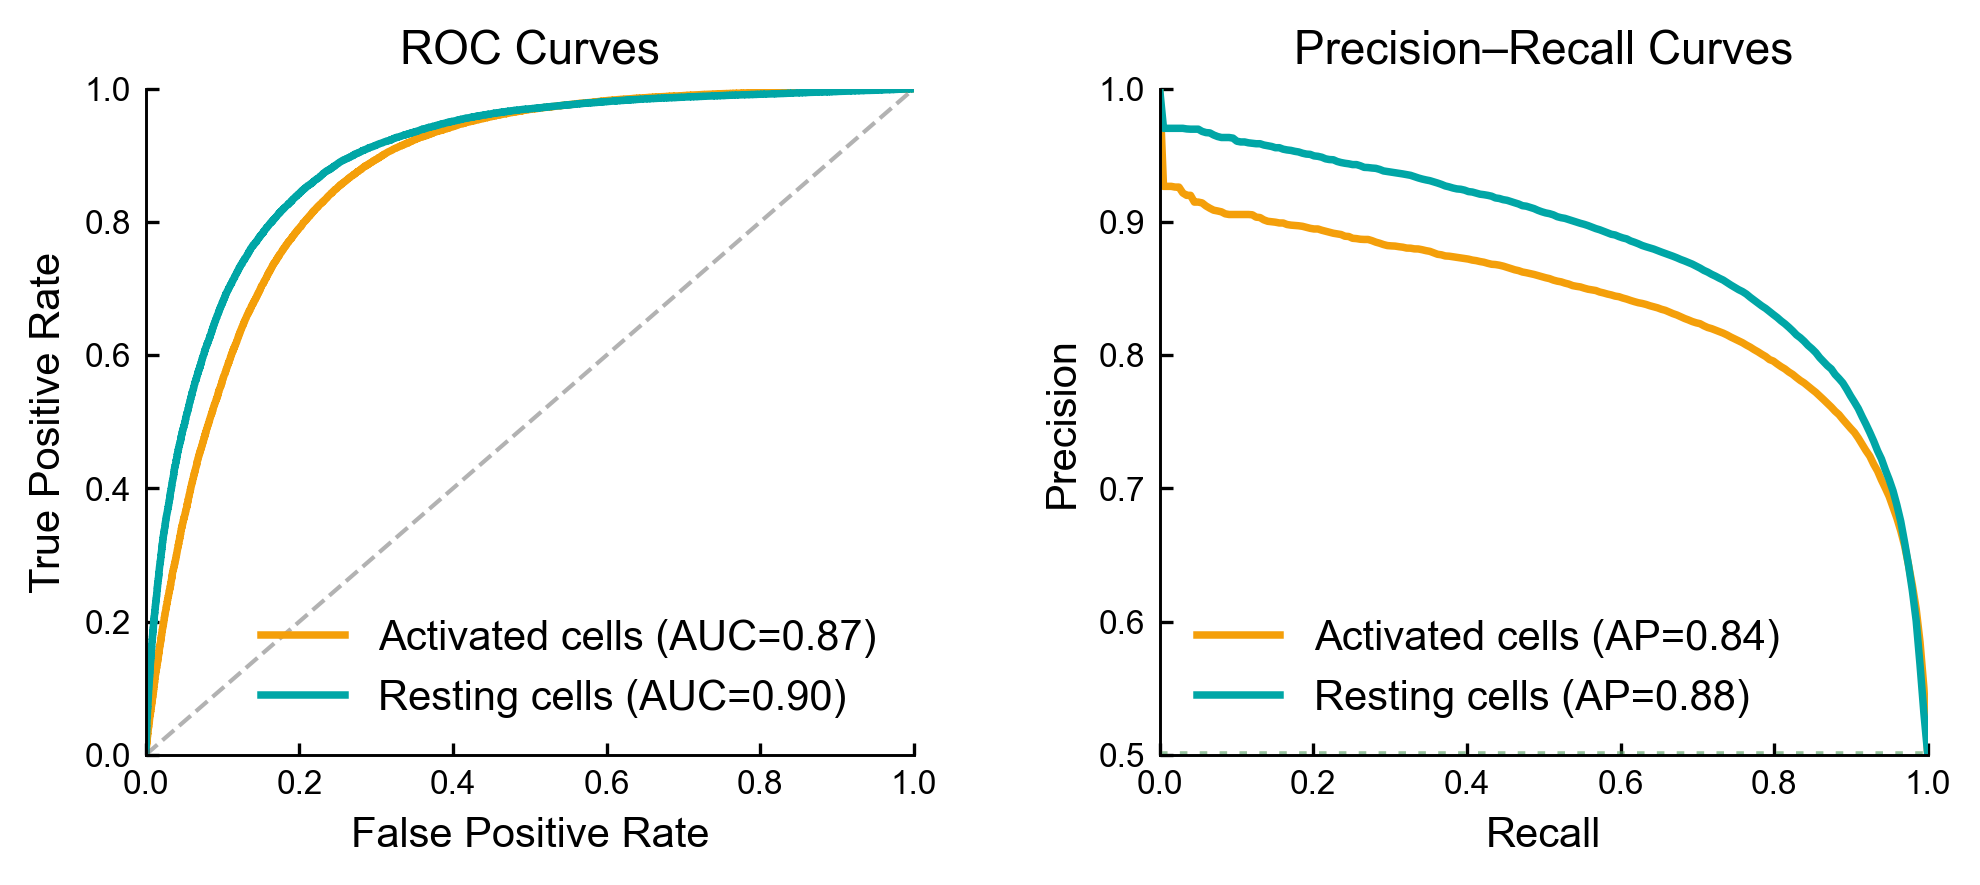

Figura generata:
 → ../images/AUC_PRAUC_fig.png


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],

    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 10,

    'figure.dpi': 300,
    'axes.linewidth': 0.7,
    'lines.linewidth': 1.8,

    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 3,
    'ytick.major.size': 3,

    'legend.frameon': False,
})

COLOR_ACT = "#F49F0A"   
COLOR_REST = "#00A6A6"  
COLOR_BASE = "#666666"  

def get_smooth_pr_curve_custom(y_true, y_probs, points=200):
    """Interpolazione Precision-Recall più liscia, stile editoriale."""
    precision, recall, _ = precision_recall_curve(y_true, y_probs)

    recall_smooth = np.linspace(0, 1, points)
    precision_smooth = np.interp(recall_smooth, recall[::-1], precision[::-1])
    precision_smooth = np.maximum.accumulate(precision_smooth[::-1])[::-1]

    return recall_smooth, precision_smooth

def plot_nature_comparison(file_act, file_rest, save_path="../images/AUC_PRAUC_fig.png"):
    
    try:
        df_act = file_act
        df_rest = file_rest
    except FileNotFoundError as e:
        print(f"❌ Errore: {e}")
        return

    y_true_act, y_probs_act = df_act['y_true'], df_act['y_pred_probs']
    y_true_rest, y_probs_rest = df_rest['y_true'], df_rest['y_pred_probs']

    auc_act = roc_auc_score(y_true_act, y_probs_act)
    auc_rest = roc_auc_score(y_true_rest, y_probs_rest)
    ap_act = average_precision_score(y_true_act, y_probs_act)
    ap_rest = average_precision_score(y_true_rest, y_probs_rest)

    base_act = y_true_act.mean()
    base_rest = y_true_rest.mean()


    fig, axes = plt.subplots(
        1, 2,
        figsize=(6.6, 3.0),   
        constrained_layout=False
    )

    plt.subplots_adjust(wspace=0.32, left=0.08, right=0.98, top=0.92, bottom=0.18)

    # ------------------------------------------
    # ROC
    # ------------------------------------------
    ax_roc = axes[0]

    fpr_act, tpr_act, _ = roc_curve(y_true_act, y_probs_act)
    fpr_rest, tpr_rest, _ = roc_curve(y_true_rest, y_probs_rest)
    
    ax_roc.plot(fpr_act, tpr_act, color=COLOR_ACT, label=f'Activated cells (AUC={auc_act:.2f})')
    ax_roc.plot(fpr_rest, tpr_rest, color=COLOR_REST, label=f'Resting cells (AUC={auc_rest:.2f})')

    ax_roc.plot([0, 1], [0, 1], linestyle='--', color=COLOR_BASE, linewidth=1, alpha=0.5)

    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.set_xlim(0, 1)
    ax_roc.set_ylim(0, 1)

    ax_roc.legend(loc="lower right")

    # ax_roc.text(-0.18, 1.05, "a", transform=ax_roc.transAxes,
    #             fontsize=13, fontweight="bold", ha="left", va="top")
    ax_roc.set_title("ROC Curves")


    # ------------------------------------------
    # PR
    # ------------------------------------------
    ax_pr = axes[1]

    rec_act, prec_act = get_smooth_pr_curve_custom(y_true_act, y_probs_act)
    rec_rest, prec_rest = get_smooth_pr_curve_custom(y_true_rest, y_probs_rest)

    ax_pr.plot(rec_act, prec_act, color=COLOR_ACT, label=f'Activated cells (AP={ap_act:.2f})')
    ax_pr.plot(rec_rest, prec_rest, color=COLOR_REST, label=f'Resting cells (AP={ap_rest:.2f})')

    ax_pr.axhline(base_act, linestyle=':', color=COLOR_ACT, alpha=0.4)
    ax_pr.axhline(base_rest, linestyle=':', color=COLOR_REST, alpha=0.4)

    ax_pr.set_xlabel("Recall")
    ax_pr.set_ylabel("Precision")
    ax_pr.set_xlim(0, 1)
    ax_pr.set_ylim(0.5, 1)

    ax_pr.legend(loc="lower left")

    # ax_pr.text(-0.18, 1.05, "b", transform=ax_pr.transAxes,
    #            fontsize=13, fontweight="bold", ha="left", va="top")
    ax_pr.set_title("Precision–Recall Curves")
    # fig.set_facecolor('#FDF7F7')
    # axes.set_style({"axes.facecolor": '#FAEFF0'})
    #plt.savefig(save_path, format="pdf")
    plt.savefig(save_path.replace(".pdf", ".png"), format="png", dpi=300)
    plt.show()

    print(f"Figura generata:\n → {save_path}")




######
#DATI
###
import pickle
from Bio.Seq import Seq

with open('../data/data_pkl/CD4T_h19_Act_tot_99_8_percentile.pkl', 'rb') as f:   
    dataset_sapiens_cd4t_act = pickle.load(f)
if True:
    for d1, d2 in zip(dataset_sapiens_cd4t_act, dataset_sapiens_cd4t_act):
        d1['sequence_rev'] = str(Seq(d1['sequence']).reverse_complement())


with open('../data/data_pkl/CD4T_h19_Rest_tot_99_8_percentile.pkl', 'rb') as f:   
    dataset_sapiens_cd4t_rest = pickle.load(f)
if True:
    for d1, d2 in zip(dataset_sapiens_cd4t_rest, dataset_sapiens_cd4t_rest):
        d1['sequence_rev'] = str(Seq(d1['sequence']).reverse_complement())


df_act = pd.DataFrame([np.array([i['label'] for i in dataset_sapiens_cd4t_act]),pd.read_pickle("../results/preds_act_model_sum_folds_08_03_26_MASK.pkl")]).T

df_rest = pd.DataFrame([np.array([i['label'] for i in dataset_sapiens_cd4t_rest]),pd.read_pickle("../results/preds_rest_model_sum_folds_08_03_26_MASK.pkl")]).T

df_act = df_act.rename(columns={0:'y_true',1:'y_pred_probs'})
df_rest = df_rest.rename(columns={0:'y_true',1:'y_pred_probs'})





# Esegui
if __name__ == "__main__":
    plot_nature_comparison(
        file_act=df_act, 
        file_rest=df_rest 
    )


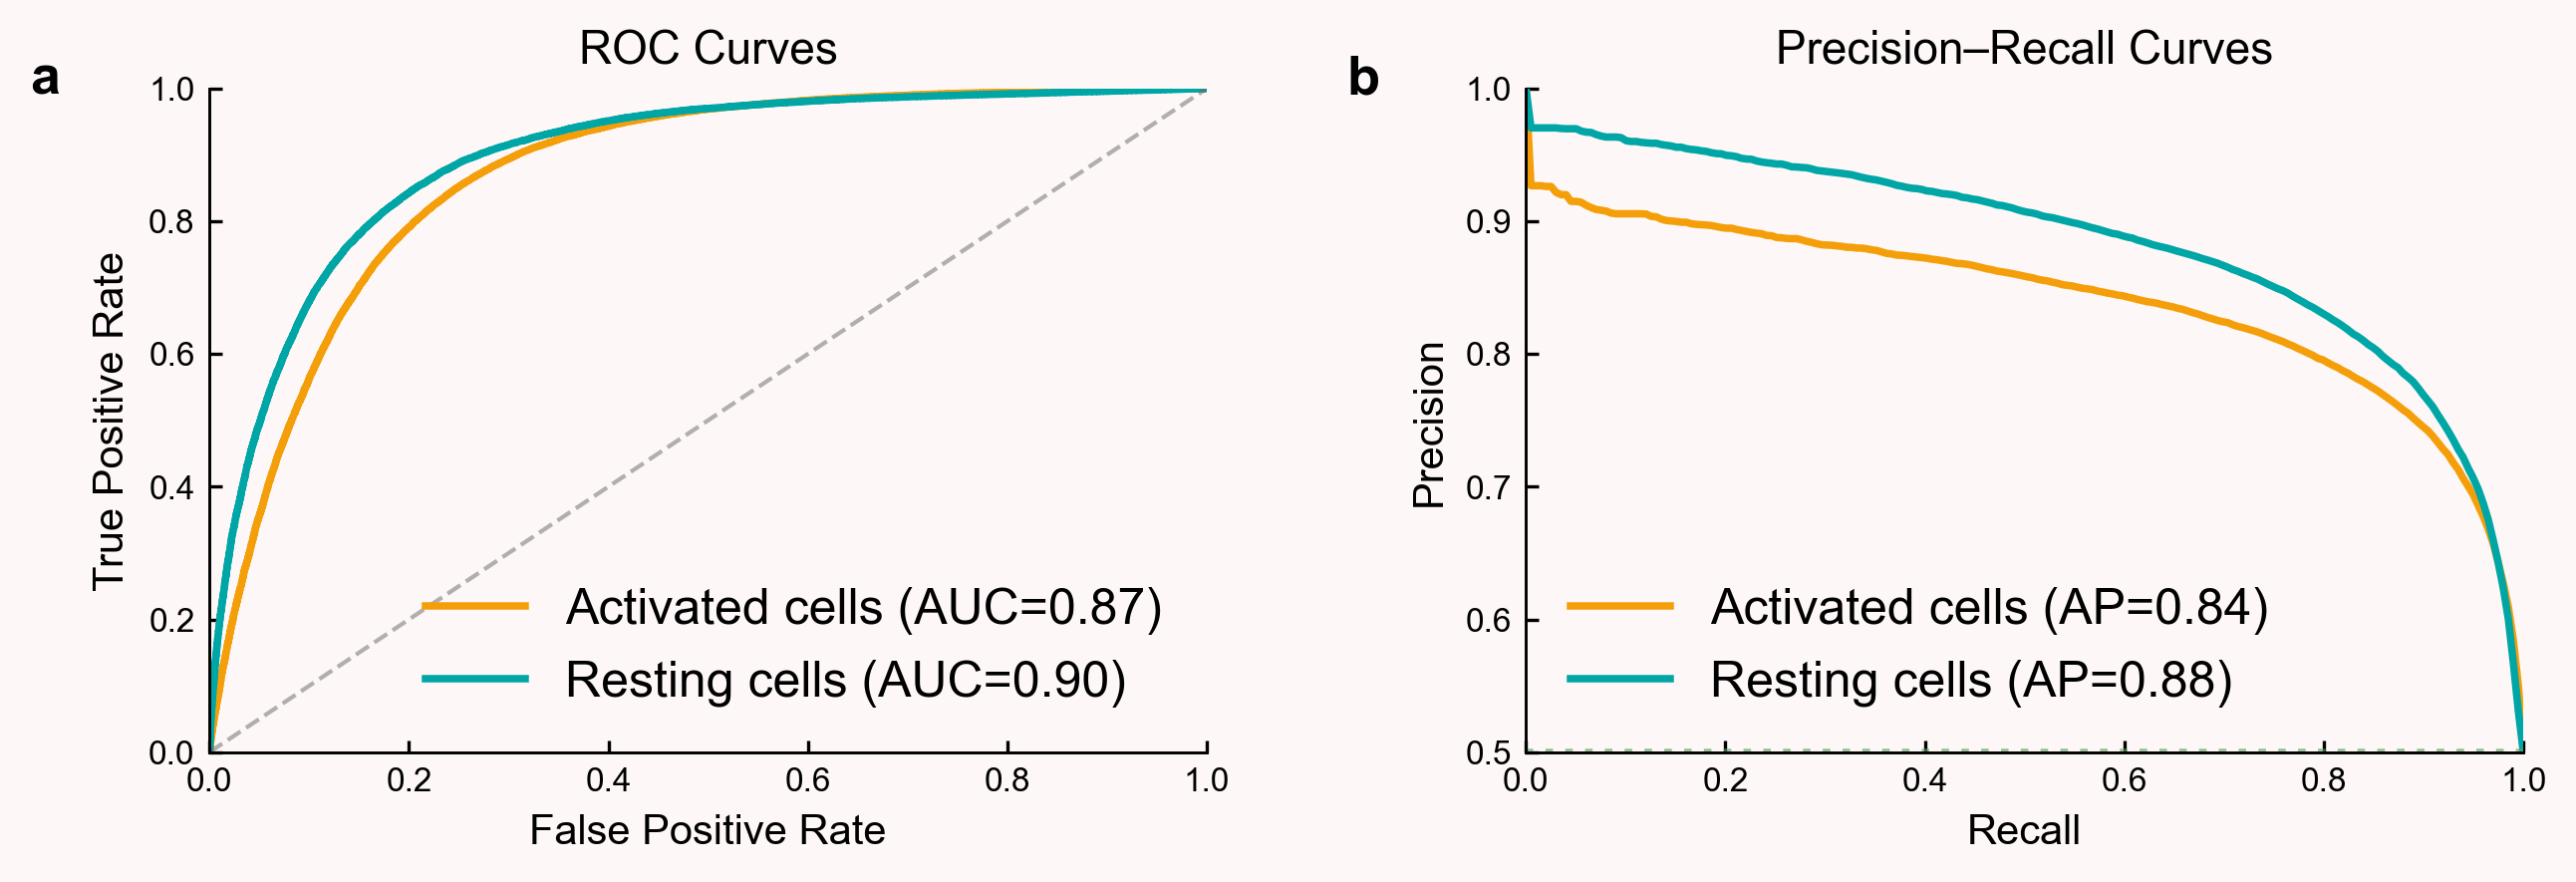

Figura generata:
 → ../images/AUC_PRAUC_fig.png


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],

    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 12,

    'figure.dpi': 300,
    'axes.linewidth': 0.7,
    'lines.linewidth': 1.8,

    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 3,
    'ytick.major.size': 3,

    'legend.frameon': False,
})

COLOR_ACT = "#F49F0A"   
COLOR_REST = "#00A6A6"  
COLOR_BASE = "#666666"  

def get_smooth_pr_curve_custom(y_true, y_probs, points=200):
    """Interpolazione Precision-Recall più liscia, stile editoriale."""
    precision, recall, _ = precision_recall_curve(y_true, y_probs)

    recall_smooth = np.linspace(0, 1, points)
    precision_smooth = np.interp(recall_smooth, recall[::-1], precision[::-1])
    precision_smooth = np.maximum.accumulate(precision_smooth[::-1])[::-1]

    return recall_smooth, precision_smooth

def plot_nature_comparison(file_act, file_rest, save_path="../images/AUC_PRAUC_fig.png"):
    
    try:
        df_act = file_act
        df_rest = file_rest
    except FileNotFoundError as e:
        print(f"❌ Errore: {e}")
        return

    y_true_act, y_probs_act = df_act['y_true'], df_act['y_pred_probs']
    y_true_rest, y_probs_rest = df_rest['y_true'], df_rest['y_pred_probs']

    auc_act = roc_auc_score(y_true_act, y_probs_act)
    auc_rest = roc_auc_score(y_true_rest, y_probs_rest)
    ap_act = average_precision_score(y_true_act, y_probs_act)
    ap_rest = average_precision_score(y_true_rest, y_probs_rest)

    base_act = y_true_act.mean()
    base_rest = y_true_rest.mean()


    fig, axes = plt.subplots(
        1, 2,
        figsize=(8.6, 3.0),   
        constrained_layout=False
    )

    plt.subplots_adjust(wspace=0.32, left=0.08, right=0.98, top=0.92, bottom=0.18)

    # ------------------------------------------
    # ROC
    # ------------------------------------------
    ax_roc = axes[0]

    fpr_act, tpr_act, _ = roc_curve(y_true_act, y_probs_act)
    fpr_rest, tpr_rest, _ = roc_curve(y_true_rest, y_probs_rest)
    
    ax_roc.plot(fpr_act, tpr_act, color=COLOR_ACT, label=f'Activated cells (AUC={auc_act:.2f})')
    ax_roc.plot(fpr_rest, tpr_rest, color=COLOR_REST, label=f'Resting cells (AUC={auc_rest:.2f})')

    ax_roc.plot([0, 1], [0, 1], linestyle='--', color=COLOR_BASE, linewidth=1, alpha=0.5)

    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.set_xlim(0, 1)
    ax_roc.set_ylim(0, 1)

    ax_roc.legend(loc="lower right")

    ax_roc.text(-0.18, 1.05, "a", transform=ax_roc.transAxes,
                fontsize=13, fontweight="bold", ha="left", va="top")
    ax_roc.set_title("ROC Curves")


    # ------------------------------------------
    # PR
    # ------------------------------------------
    ax_pr = axes[1]

    rec_act, prec_act = get_smooth_pr_curve_custom(y_true_act, y_probs_act)
    rec_rest, prec_rest = get_smooth_pr_curve_custom(y_true_rest, y_probs_rest)

    ax_pr.plot(rec_act, prec_act, color=COLOR_ACT, label=f'Activated cells (AP={ap_act:.2f})')
    ax_pr.plot(rec_rest, prec_rest, color=COLOR_REST, label=f'Resting cells (AP={ap_rest:.2f})')

    ax_pr.axhline(base_act, linestyle=':', color=COLOR_ACT, alpha=0.4)
    ax_pr.axhline(base_rest, linestyle=':', color=COLOR_REST, alpha=0.4)

    ax_pr.set_xlabel("Recall")
    ax_pr.set_ylabel("Precision")
    ax_pr.set_xlim(0, 1)
    ax_pr.set_ylim(0.5, 1)

    ax_pr.legend(loc="lower left")

    ax_pr.text(-0.18, 1.05, "b", transform=ax_pr.transAxes,
               fontsize=13, fontweight="bold", ha="left", va="top")
    ax_pr.set_title("Precision–Recall Curves")
    fig.set_facecolor('#FDF7F7')
    # axes.set_style({"axes.facecolor": '#FAEFF0'})
    #plt.savefig(save_path, format="pdf")
    plt.savefig(save_path.replace(".pdf", ".png"), format="png", dpi=300)
    plt.show()

    print(f"Figura generata:\n → {save_path}")




######
#DATI
###
import pickle
from Bio.Seq import Seq

with open('../data/data_pkl/CD4T_h19_Act_tot_99_8_percentile.pkl', 'rb') as f:   
    dataset_sapiens_cd4t_act = pickle.load(f)
if True:
    for d1, d2 in zip(dataset_sapiens_cd4t_act, dataset_sapiens_cd4t_act):
        d1['sequence_rev'] = str(Seq(d1['sequence']).reverse_complement())


with open('../data/data_pkl/CD4T_h19_Rest_tot_99_8_percentile.pkl', 'rb') as f:   
    dataset_sapiens_cd4t_rest = pickle.load(f)
if True:
    for d1, d2 in zip(dataset_sapiens_cd4t_rest, dataset_sapiens_cd4t_rest):
        d1['sequence_rev'] = str(Seq(d1['sequence']).reverse_complement())


df_act = pd.DataFrame([np.array([i['label'] for i in dataset_sapiens_cd4t_act]),pd.read_pickle("../results/preds_act_model_sum_folds_08_03_26_MASK.pkl")]).T

df_rest = pd.DataFrame([np.array([i['label'] for i in dataset_sapiens_cd4t_rest]),pd.read_pickle("../results/preds_rest_model_sum_folds_08_03_26_MASK.pkl")]).T

df_act = df_act.rename(columns={0:'y_true',1:'y_pred_probs'})
df_rest = df_rest.rename(columns={0:'y_true',1:'y_pred_probs'})





# Esegui
if __name__ == "__main__":
    plot_nature_comparison(
        file_act=df_act, 
        file_rest=df_rest 
    )


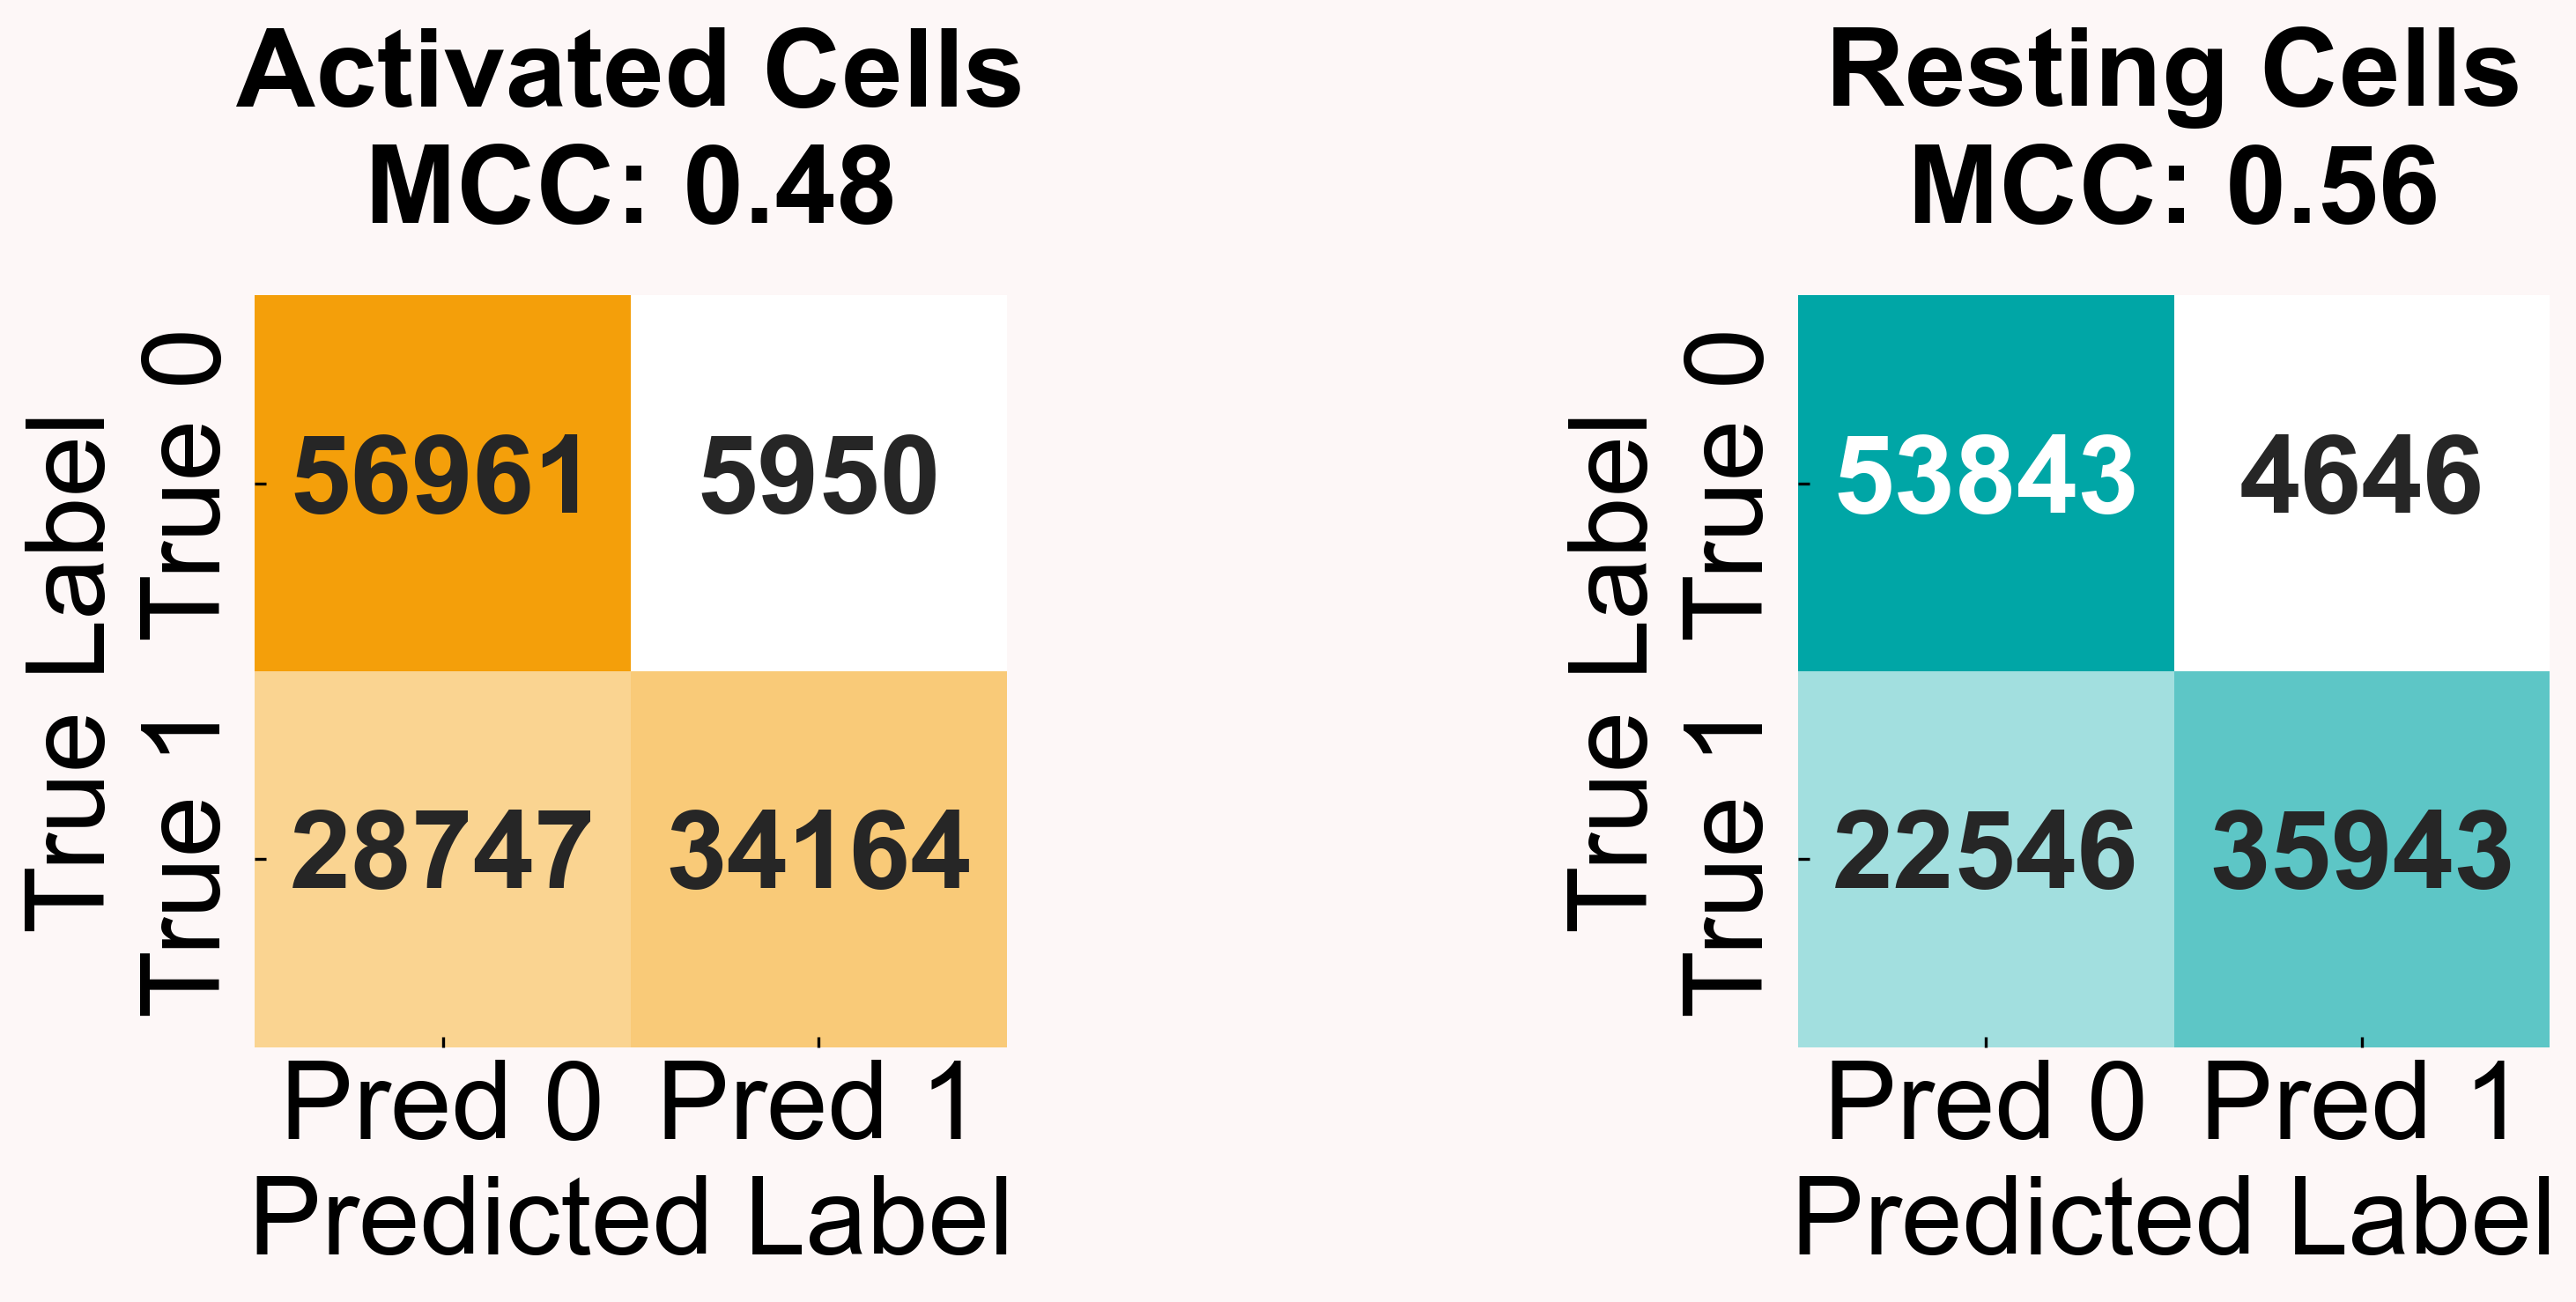

In [5]:
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import confusion_matrix, matthews_corrcoef

def plot_custom_confusion_matrices(df_act, df_rest, threshold=0.5):
    # Creazione di colormap personalizzate che sfumano dal bianco ai tuoi colori
    cmap_act = LinearSegmentedColormap.from_list("act_cmap", ["#ffffff", COLOR_ACT])
    cmap_rest = LinearSegmentedColormap.from_list("rest_cmap", ["#ffffff", COLOR_REST])
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    datasets = [
        (df_act, "Activated Cells", axes[0], cmap_act),
        (df_rest, "Resting Cells", axes[1], cmap_rest)
    ]
    
    for df, title, ax, cmap in datasets:
        # Calcolo predizioni e metrica
        y_pred = (df['y_pred_probs'] >= threshold).astype(int)
        y_true = df['y_true'].astype(int)
        mcc = matthews_corrcoef(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        
        # Plot della Heatmap
        sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap=cmap, 
                    cbar=False, square=True,
                    annot_kws={"size": 30, "weight": "bold"}, # Numeri dentro i quadrati
                    xticklabels=['Pred 0', 'Pred 1'],
                    yticklabels=['True 0', 'True 1'])
        
        # Formattazione Font
        ax.set_title(f"{title}\nMCC: {mcc:.2f}", fontsize=30, pad=20, fontweight='bold')
        ax.set_xlabel("Predicted Label", fontsize=30)
        ax.set_ylabel("True Label", fontsize=30)
        ax.tick_params(axis='both', which='major', labelsize=30)
    fig.set_facecolor('#FDF7F7')
    sns.set_style({"axes.facecolor": '#FDF7F7'})
    plt.tight_layout()
    plt.savefig('conf_mat'.replace(".pdf", ".png"), format="png", dpi=300)

    plt.show()

# Esecuzione
if __name__ == "__main__":
    plot_custom_confusion_matrices(df_act, df_rest)

In [11]:
#df_act = pd.DataFrame([np.array([i['label'] for i in dataset_sapiens_cd4t_act]),pd.read_pickle("../results/preds_act_model_sum_folds_16_02_26.pkl")]).T
df_act = pd.DataFrame([np.array([i['label'] for i in dataset_sapiens_cd4t_act]),pd.read_pickle("../results/preds_act_model_sum_folds_08_03_26_MASK.pkl")]).T

#df_rest = pd.DataFrame([np.array([i['label'] for i in dataset_sapiens_cd4t_rest]),pd.read_pickle("../results/preds_rest_model_sum_folds_16_02_26.pkl")]).T
df_rest = pd.DataFrame([np.array([i['label'] for i in dataset_sapiens_cd4t_rest]),pd.read_pickle("../results/preds_rest_model_sum_folds_08_03_26_MASK.pkl")]).T

df_act = df_act.rename(columns={0:'y_true',1:'y_pred_probs'})
df_rest = df_rest.rename(columns={0:'y_true',1:'y_pred_probs'})



[Activated Cells] Best Threshold: 0.26 (MCC: 0.607)
[Resting Cells] Best Threshold: 0.28 (MCC: 0.645)


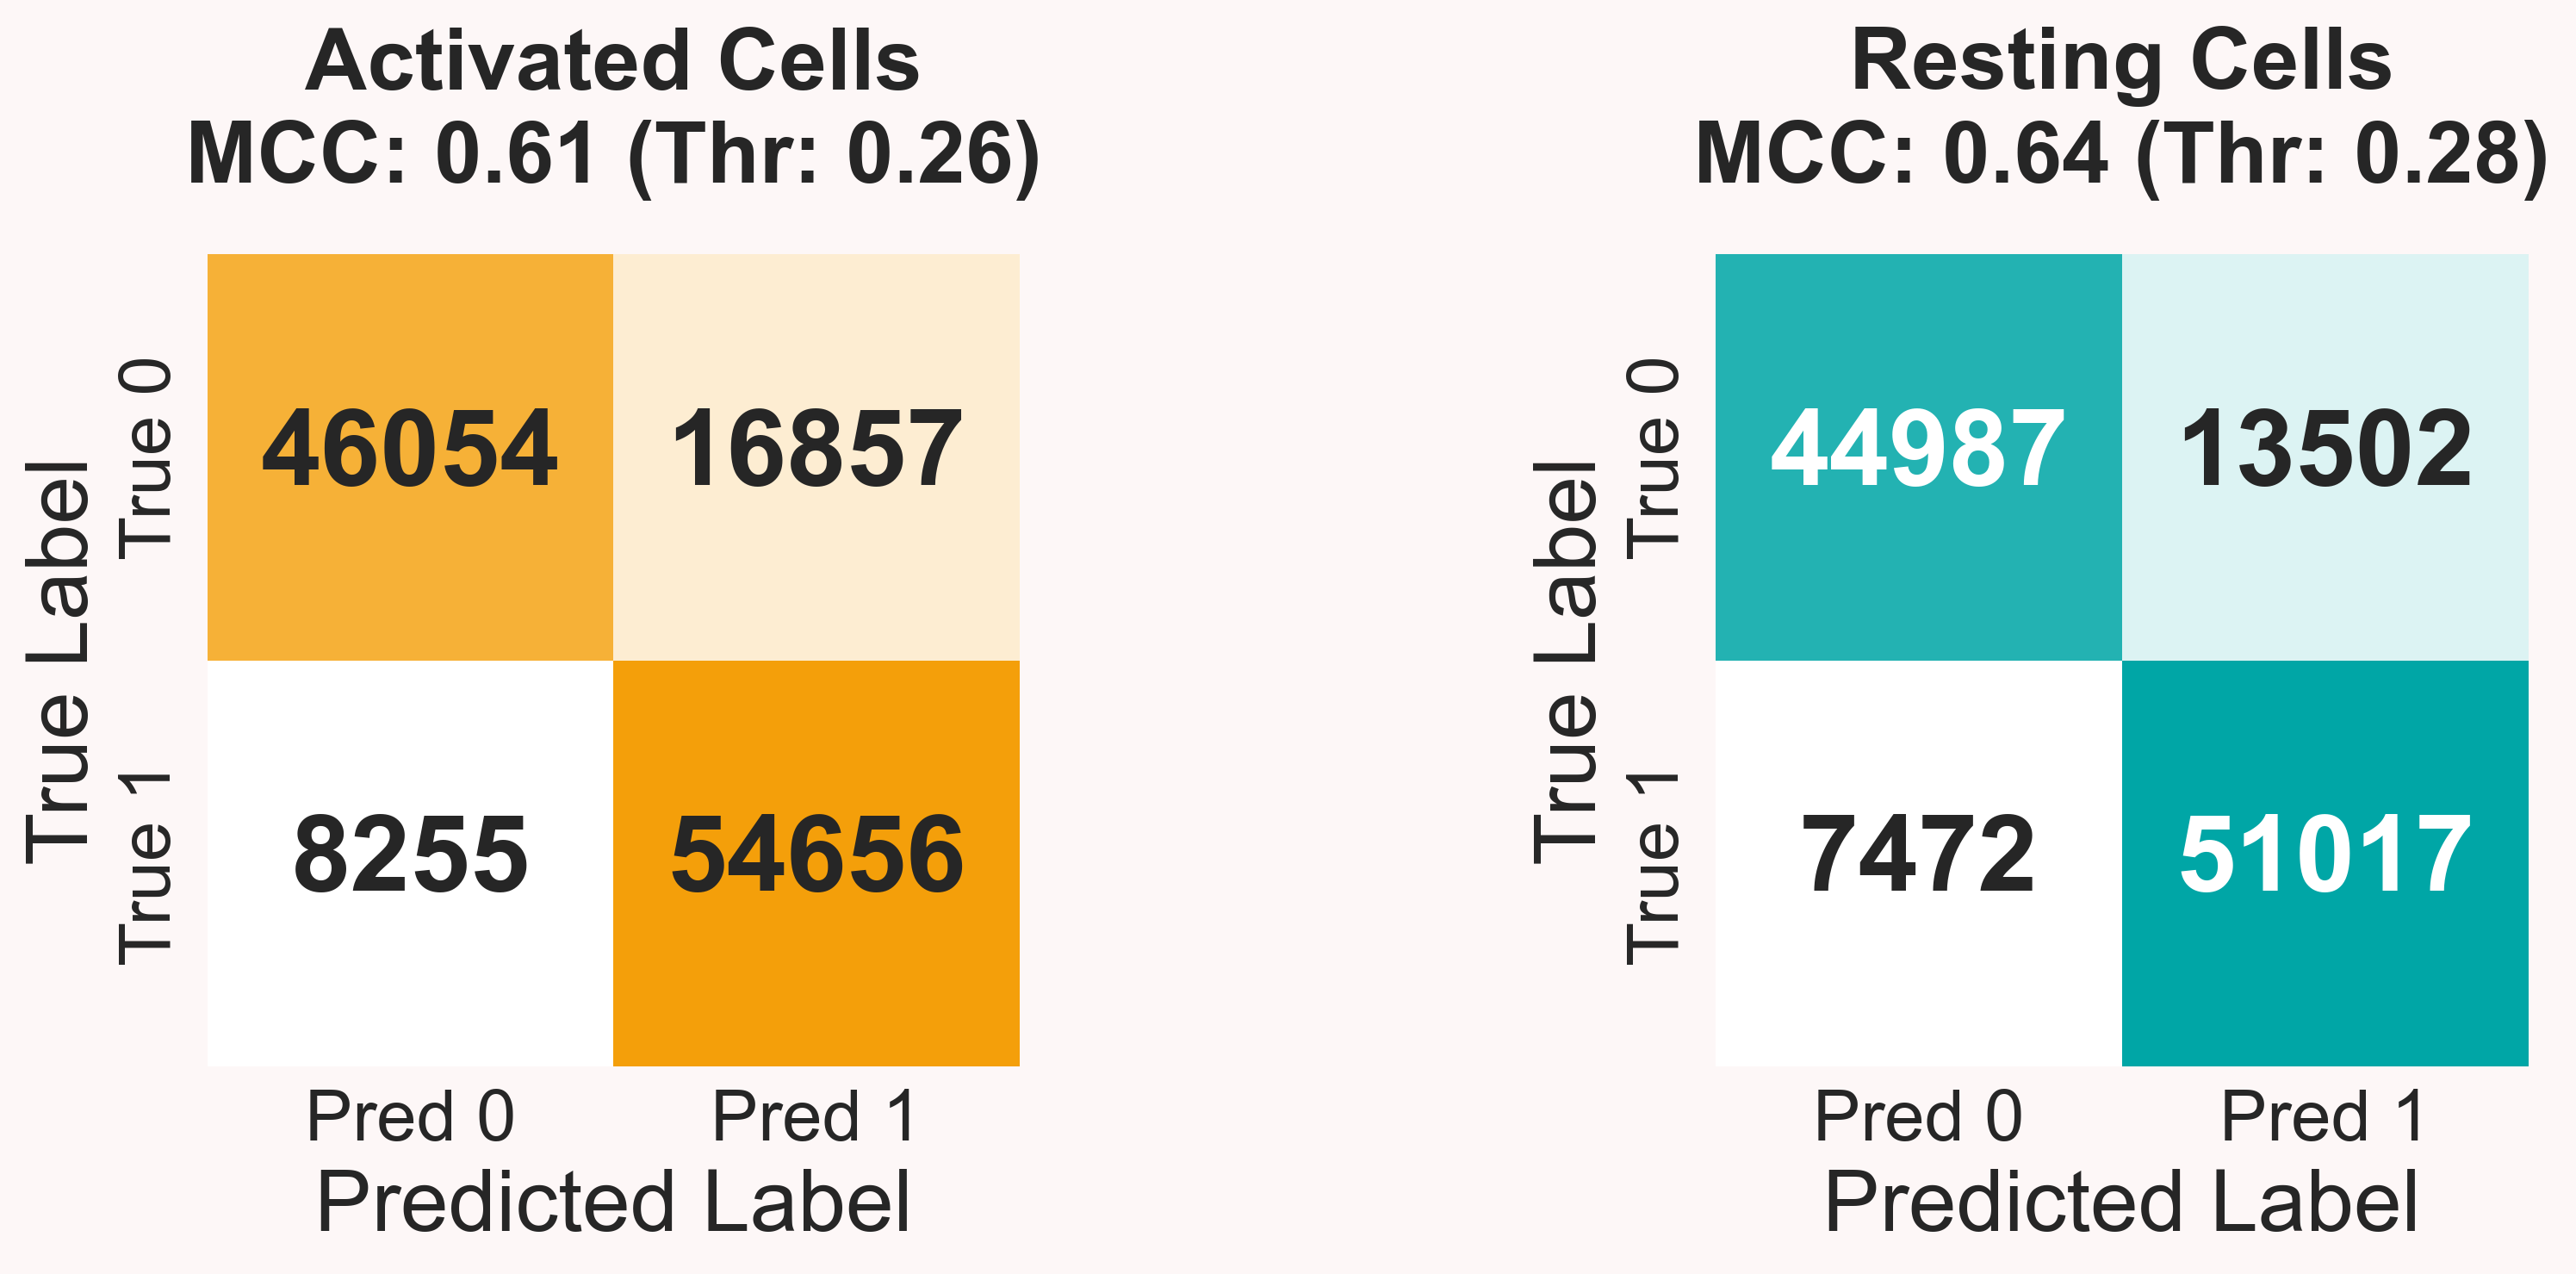

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import confusion_matrix, matthews_corrcoef

# Assicurati di aver definito COLOR_ACT e COLOR_REST nel tuo script
# COLOR_ACT = "#D4880F" 
# COLOR_REST = "#006B7D"

def plot_custom_confusion_matrices(df_act, df_rest):
    # Creazione di colormap personalizzate che sfumano dal bianco ai tuoi colori
    cmap_act = LinearSegmentedColormap.from_list("act_cmap", ["#ffffff", COLOR_ACT])
    cmap_rest = LinearSegmentedColormap.from_list("rest_cmap", ["#ffffff", COLOR_REST])
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    datasets = [
        (df_act, "Activated Cells", axes[0], cmap_act),
        (df_rest, "Resting Cells", axes[1], cmap_rest)
    ]
    
    for df, title, ax, cmap in datasets:
        y_true = df['y_true'].astype(int)
        y_probs = df['y_pred_probs']
        
        # --- RICERCA DELLA BEST THRESHOLD PER IL BEST MCC ---
        best_mcc = -1.0
        best_thresh = 0.5
        
        # Scansioniamo 100 possibili soglie tra 0 e 1
        thresholds = np.linspace(0, 1, 101)
        for t in thresholds:
            y_pred_temp = (y_probs >= t).astype(int)
            # Evitiamo calcoli inutili se la soglia assegna tutto a una singola classe
            if len(np.unique(y_pred_temp)) == 1:
                current_mcc = 0.0
            else:
                current_mcc = matthews_corrcoef(y_true, y_pred_temp)
            
            if current_mcc > best_mcc:
                best_mcc = current_mcc
                best_thresh = t
                
        print(f"[{title}] Best Threshold: {best_thresh:.2f} (MCC: {best_mcc:.3f})")
        
        # --- CALCOLO FINALE CON LA BEST THRESHOLD ---
        y_pred = (y_probs >= best_thresh).astype(int)
        cm = confusion_matrix(y_true, y_pred)
        
        # Plot della Heatmap
        sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap=cmap, 
                    cbar=False, square=True,
                    annot_kws={"size": 30, "weight": "bold"}, # Numeri dentro i quadrati
                    xticklabels=['Pred 0', 'Pred 1'],
                    yticklabels=['True 0', 'True 1'])
        
        # Formattazione Font (ora include anche la soglia usata)
        ax.set_title(f"{title}\nMCC: {best_mcc:.2f} (Thr: {best_thresh:.2f})", 
                     fontsize=24, pad=20, fontweight='bold')
        ax.set_xlabel("Predicted Label", fontsize=24)
        ax.set_ylabel("True Label", fontsize=24)
        ax.tick_params(axis='both', which='major', labelsize=20)
        
    fig.set_facecolor('#FDF7F7')
    sns.set_style({"axes.facecolor": '#FDF7F7'})
    plt.tight_layout()
    plt.savefig('conf_mat.png', format="png", dpi=300)
    plt.show()


plot_custom_confusion_matrices(df_act, df_rest)

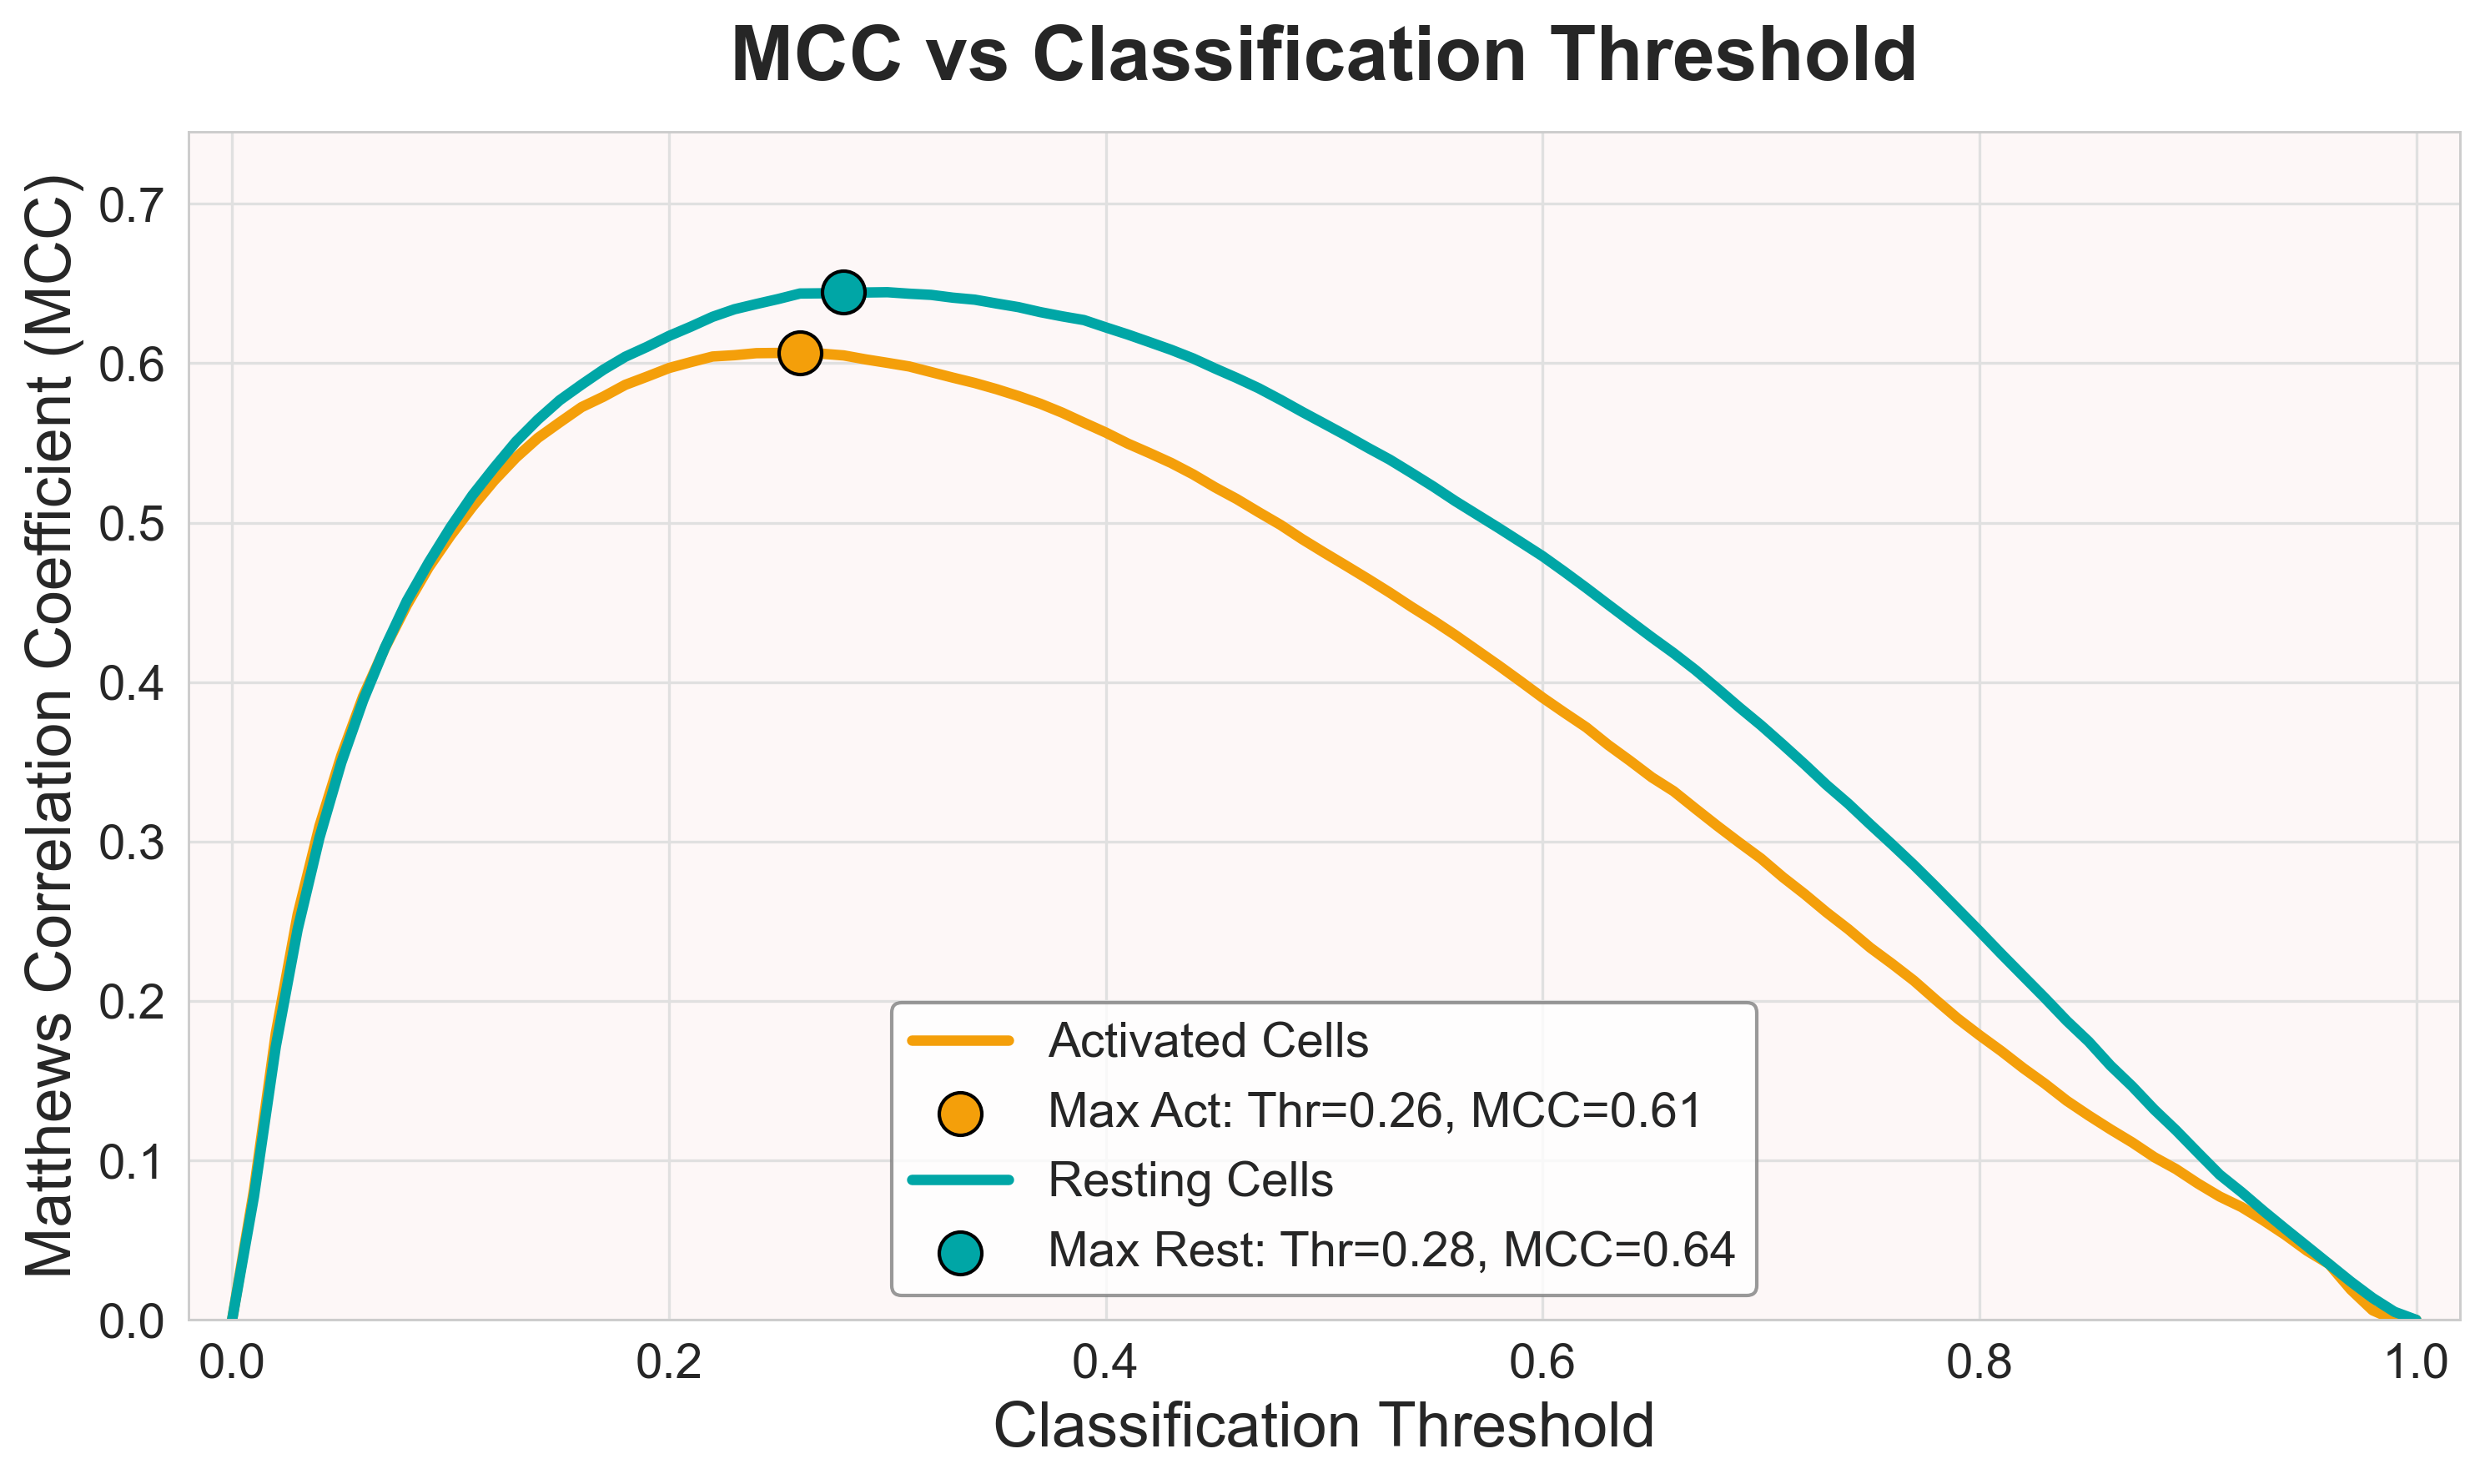

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import matthews_corrcoef

# Assicurati di avere i colori definiti
# COLOR_ACT = "#D4880F" 
# COLOR_REST = "#006B7D"

def plot_mcc_vs_threshold(df_act, df_rest):
    # Creiamo l'array delle soglie da testare (da 0.0 a 1.0)
    thresholds = np.linspace(0, 1, 101)
    
    # Liste per salvare i risultati
    mcc_act = []
    mcc_rest = []
    
    # Estraiamo i veri valori e le probabilità
    y_true_act = df_act['y_true'].astype(int)
    y_probs_act = df_act['y_pred_probs']
    
    y_true_rest = df_rest['y_true'].astype(int)
    y_probs_rest = df_rest['y_pred_probs']
    
    # Calcolo dell'MCC per ogni soglia
    for t in thresholds:
        # Activated
        pred_act = (y_probs_act >= t).astype(int)
        if len(np.unique(pred_act)) == 1:
            mcc_act.append(0.0)
        else:
            mcc_act.append(matthews_corrcoef(y_true_act, pred_act))
            
        # Resting
        pred_rest = (y_probs_rest >= t).astype(int)
        if len(np.unique(pred_rest)) == 1:
            mcc_rest.append(0.0)
        else:
            mcc_rest.append(matthews_corrcoef(y_true_rest, pred_rest))
            
    # Troviamo i punti di massimo per tracciare i marker
    best_idx_act = np.argmax(mcc_act)
    best_idx_rest = np.argmax(mcc_rest)
    
    # --- PLOTTING ---
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid", {"axes.facecolor": '#FDF7F7', "grid.color": "#e0e0e0"})
    
    # Curva Activated
    plt.plot(thresholds, mcc_act, label='Activated Cells', color=COLOR_ACT, linewidth=3)
    plt.scatter(thresholds[best_idx_act], mcc_act[best_idx_act], 
                color=COLOR_ACT, s=150, zorder=5, edgecolor='black', 
                label=f'Max Act: Thr={thresholds[best_idx_act]:.2f}, MCC={mcc_act[best_idx_act]:.2f}')
    
    # Curva Resting
    plt.plot(thresholds, mcc_rest, label='Resting Cells', color=COLOR_REST, linewidth=3)
    plt.scatter(thresholds[best_idx_rest], mcc_rest[best_idx_rest], 
                color=COLOR_REST, s=150, zorder=5, edgecolor='black', 
                label=f'Max Rest: Thr={thresholds[best_idx_rest]:.2f}, MCC={mcc_rest[best_idx_rest]:.2f}')
    
    # Formattazione del grafico
    plt.title("MCC vs Classification Threshold", fontsize=22, fontweight='bold', pad=15)
    plt.xlabel("Classification Threshold", fontsize=18)
    plt.ylabel("Matthews Correlation Coefficient (MCC)", fontsize=18)
    
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlim(-0.02, 1.02)
    plt.ylim(0, max(max(mcc_act), max(mcc_rest)) + 0.1) # Lascia un po' di respiro in alto
    
    # Legenda
    plt.legend(fontsize=14, loc='lower center', frameon=True, facecolor='white', edgecolor='gray')
    
    plt.tight_layout()
    plt.savefig('mcc_vs_threshold.png', format="png", dpi=300)
    plt.show()

# Esecuzione
plot_mcc_vs_threshold(df_act, df_rest)